# FineBio 3D Reconstruction Pipeline

This notebook implements a 3D reconstruction approach for FineBio videos:
1. **Multi-view geometry**: Use FPV + TPV camera calibration to reconstruct 3D scene
2. **3D object detection**: Triangulate YOLO detections from both views → 3D positions
3. **3D features**: Extract spatial relationships (distances, angles, interactions) in 3D space
4. **Action segmentation**: Use 3D features for better verb/manipulated/affected object detection

## Why 3D?
- **Better spatial understanding**: True 3D positions vs 2D bboxes
- **Occlusion handling**: Multiple views → complete 3D scene
- **Robust manipulation detection**: 3D hand-object distances more reliable
- **Spatial relationships**: Distance/angle features in 3D space

In [108]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import zipfile
import json
from typing import List, Dict, Optional, Tuple
from dataclasses import dataclass
from collections import Counter
import ultralytics
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

# Set paths
DATASET_PATH = Path("/home/nyan/FineBio")
CAMERA_POSES_PATH = DATASET_PATH / "14 misc" / "finebio_camera_poses.zip"
ANNOTATIONS_DIR = DATASET_PATH / "01 annotations"
ACTION_DIR = ANNOTATIONS_DIR / "finebio_action_annotations"

# Load YOLO model (fine-tuned on FineBio)
YOLO_MODEL_PATH = "/home/nyan/k-project/runs/detect/runs/finebio_yolo26/yolo26n_joint3/weights/best.pt"
yolo_model = ultralytics.YOLO(YOLO_MODEL_PATH)

print("Loaded YOLO model:", YOLO_MODEL_PATH)

Loaded YOLO model: /home/nyan/k-project/runs/detect/runs/finebio_yolo26/yolo26n_joint3/weights/best.pt


In [109]:
# Pose model (person + keypoints) for stable ROI
# This is the model that gives us "person" and wrist locations.
POSE_MODEL_PATH = "yolov8n-pose.pt"  # downloads automatically via ultralytics
pose_model = ultralytics.YOLO(POSE_MODEL_PATH)
print("Loaded pose model:", POSE_MODEL_PATH)

# COCO keypoint indices for YOLOv8-pose
COCO_LEFT_WRIST = 9
COCO_RIGHT_WRIST = 10


Loaded pose model: yolov8n-pose.pt


In [110]:
# Load camera calibration data (from aruco_detection.ipynb)

def load_camera_poses_data(poses_zip_path):
    """Load camera poses data from zip file"""
    import tempfile
    intrinsic_params = {}
    marker_points = {}
    extrinsics = {}
    fp_poses = {}
    temp_dir = Path(tempfile.mkdtemp())
    
    try:
        with zipfile.ZipFile(poses_zip_path, 'r') as z:
            z.extractall(temp_dir)
            
            # Load intrinsic parameters
            intrinsic_dir = temp_dir / "finebio_camera_poses" / "intrinsic_parameters"
            if intrinsic_dir.exists():
                for npz_file in intrinsic_dir.glob("*.npz"):
                    data = np.load(npz_file, allow_pickle=True)
                    intrinsic_params[npz_file.stem] = {k: data[k] for k in data.keys()}
            
            # Load marker points and extrinsics
            marker_dir = temp_dir / "finebio_camera_poses" / "third_person_camera_poses"
            if marker_dir.exists():
                for date_dir in marker_dir.iterdir():
                    if date_dir.is_dir():
                        marker_file = date_dir / "params" / "marker_points.npy"
                        if marker_file.exists():
                            marker_points[date_dir.name] = np.load(marker_file, allow_pickle=True)
                        
                        extrinsics_dir = date_dir / "extrinsics"
                        if extrinsics_dir.exists():
                            extrinsics[date_dir.name] = {}
                            for extr_file in extrinsics_dir.glob("*.npz"):
                                data = np.load(extr_file, allow_pickle=True)
                                extrinsics[date_dir.name][extr_file.stem] = {k: data[k] for k in data.keys()}
            
            # Load first-person camera poses
            fp_poses_dir = temp_dir / "finebio_camera_poses" / "first_person_camera_poses"
            if fp_poses_dir.exists():
                for npz_file in fp_poses_dir.glob("*.npz"):
                    data = np.load(npz_file, allow_pickle=True)
                    fp_poses[npz_file.stem] = {k: data[k] for k in data.keys()}
            
        return intrinsic_params, marker_points, extrinsics, fp_poses, temp_dir
    except Exception as e:
        print(f"Error loading camera poses: {e}")
        return None, None, None, None, None

# Load calibration data
print("Loading camera calibration data...")
intrinsic_params, marker_points, extrinsics, fp_poses, temp_dir = load_camera_poses_data(CAMERA_POSES_PATH)

if intrinsic_params:
    print(f"Loaded {len(intrinsic_params)} camera intrinsic parameter sets")
if extrinsics:
    print(f"Loaded extrinsics for {len(extrinsics)} dates")
if fp_poses:
    print(f"Loaded {len(fp_poses)} first-person camera poses")

Loading camera calibration data...
Loaded 2 camera intrinsic parameter sets
Loaded extrinsics for 10 dates
Loaded 226 first-person camera poses


In [111]:
# Helper: Get camera matrices for an instance
# (We'll need to match instance_id to date/calibration data)

def get_camera_matrices(instance_id: str, intrinsic_params, extrinsics, fp_poses):
    """
    Get camera intrinsic and extrinsic matrices for FPV and TPV cameras.
    
    Returns:
        K_fpv, K_tpv: Intrinsic matrices (3x3)
        R_fpv, t_fpv: FPV rotation (3x3) and translation (3x1)
        R_tpv, t_tpv: TPV rotation (3x3) and translation (3x1)
    """
    # TODO: Match instance_id to date/calibration set
    # For now, use first available calibration
    
    # Get intrinsics (assume same for all cameras of same type)
    if 'fpv' in intrinsic_params:
        K_fpv_data = intrinsic_params['fpv']
        K_fpv = K_fpv_data.get('camera_matrix', np.eye(3))
    else:
        # Fallback: use default camera matrix (will need proper calibration)
        K_fpv = np.array([[800, 0, 320], [0, 800, 240], [0, 0, 1]], dtype=np.float32)
    
    if 'tpv' in intrinsic_params or len(intrinsic_params) > 0:
        # Use first available intrinsic
        first_key = list(intrinsic_params.keys())[0]
        K_tpv_data = intrinsic_params[first_key]
        K_tpv = K_tpv_data.get('camera_matrix', np.eye(3))
    else:
        K_tpv = np.array([[800, 0, 320], [0, 800, 240], [0, 0, 1]], dtype=np.float32)
    
    # Get extrinsics (rotation + translation)
    # FPV: from fp_poses (first-person camera)
    if fp_poses and len(fp_poses) > 0:
        first_fpv = list(fp_poses.values())[0]
        R_fpv = first_fpv.get('R', np.eye(3))
        t_fpv = first_fpv.get('t', np.zeros((3, 1)))
    else:
        R_fpv = np.eye(3)
        t_fpv = np.zeros((3, 1))
    
    # TPV: from extrinsics (third-person camera)
    if extrinsics and len(extrinsics) > 0:
        first_date = list(extrinsics.keys())[0]
        first_cam = list(extrinsics[first_date].keys())[0]
        tpv_data = extrinsics[first_date][first_cam]
        R_tpv = tpv_data.get('R', np.eye(3))
        t_tpv = tpv_data.get('t', np.zeros((3, 1)))
    else:
        R_tpv = np.eye(3)
        t_tpv = np.array([[0], [0], [2.0]])  # TPV typically 2m away
    
    return K_fpv, K_tpv, R_fpv, t_fpv, R_tpv, t_tpv

print("Camera matrix helper function defined")

Camera matrix helper function defined


In [112]:
# 3D Triangulation: Match YOLO detections across views → 3D positions

def triangulate_point(p1, p2, K1, R1, t1, K2, R2, t2):
    """
    Triangulate 3D point from 2D correspondences in two views.
    
    Args:
        p1, p2: 2D points (x, y) in image coordinates
        K1, K2: Intrinsic matrices (3x3)
        R1, t1: Rotation (3x3) and translation (3x1) for camera 1
        R2, t2: Rotation (3x3) and translation (3x1) for camera 2
    
    Returns:
        P: 3D point (X, Y, Z) in world coordinates
    """
    # Projection matrices: P = K [R|t]
    P1 = K1 @ np.hstack([R1, t1])
    P2 = K2 @ np.hstack([R2, t2])
    
    # Triangulate using DLT (Direct Linear Transform)
    A = np.array([
        p1[0] * P1[2, :] - P1[0, :],
        p1[1] * P1[2, :] - P1[1, :],
        p2[0] * P2[2, :] - P2[0, :],
        p2[1] * P2[2, :] - P2[1, :]
    ])
    
    # Solve Ax = 0 using SVD
    _, _, Vt = np.linalg.svd(A)
    P_homogeneous = Vt[-1, :]
    
    # Convert from homogeneous to 3D
    if abs(P_homogeneous[3]) > 1e-6:
        P = P_homogeneous[:3] / P_homogeneous[3]
    else:
        P = P_homogeneous[:3]
    
    return P


def match_detections_across_views(dets_fpv, dets_tpv, K_fpv, R_fpv, t_fpv, K_tpv, R_tpv, t_tpv, 
                                   iou_threshold=0.3, max_reprojection_error=200.0):
    """
    Match YOLO detections from FPV and TPV views based on:
    1. Class name (must match)
    2. Geometric consistency (reprojection error)
    3. IoU in epipolar geometry
    
    Returns:
        matches: List of (det_fpv_idx, det_tpv_idx, P_3d) tuples
    """
    matches = []
    
    for i, det_fpv in enumerate(dets_fpv):
        if det_fpv is None:
            continue
        class_fpv = det_fpv.get('class_name', '')
        bbox_fpv = det_fpv.get('bbox', [])  # [x1, y1, x2, y2]
        center_fpv = [(bbox_fpv[0] + bbox_fpv[2]) / 2, (bbox_fpv[1] + bbox_fpv[3]) / 2]
        
        best_match = None
        best_error = float('inf')
        
        for j, det_tpv in enumerate(dets_tpv):
            if det_tpv is None:
                continue
            class_tpv = det_tpv.get('class_name', '')
            
            # Must be same class
            if class_fpv != class_tpv:
                continue
            
            bbox_tpv = det_tpv.get('bbox', [])
            center_tpv = [(bbox_tpv[0] + bbox_tpv[2]) / 2, (bbox_tpv[1] + bbox_tpv[3]) / 2]
            
            # Triangulate 3D point
            try:
                P_3d = triangulate_point(
                    np.array(center_fpv), np.array(center_tpv),
                    K_fpv, R_fpv, t_fpv, K_tpv, R_tpv, t_tpv
                )
                
                # Check reprojection error
                # Project 3D point back to both views
                P_hom = np.append(P_3d, 1.0)
                proj_fpv = (K_fpv @ (R_fpv @ P_3d + t_fpv.ravel()))[:2]
                proj_tpv = (K_tpv @ (R_tpv @ P_3d + t_tpv.ravel()))[:2]
                
                error_fpv = np.linalg.norm(proj_fpv - center_fpv)
                error_tpv = np.linalg.norm(proj_tpv - center_tpv)
                total_error = error_fpv + error_tpv
                
                if total_error < max_reprojection_error and total_error < best_error:
                    best_match = (i, j, P_3d)
                    best_error = total_error
            except:
                continue
        
        if best_match:
            matches.append(best_match)
    
    return matches

print("Triangulation and matching functions defined")

Triangulation and matching functions defined


In [113]:
# Build 3D features from reconstructed scene

@dataclass
class Object3D:
    """3D object representation"""
    class_name: str
    position: np.ndarray  # (3,) XYZ in world coordinates
    confidence: float
    bbox_fpv: Optional[List[float]] = None
    bbox_tpv: Optional[List[float]] = None

def compute_3d_features(objects_3d: List[Object3D], hands_3d: List[Object3D]) -> np.ndarray:
    """
    Extract 3D spatial features from reconstructed scene.
    
    Features:
    1. Object positions (normalized)
    2. Hand-object distances (for each hand-object pair)
    3. Object-object distances (for nearby objects)
    4. Hand-object angles (direction vectors)
    5. Object counts per class (in 3D space)
    
    Returns:
        features: (D,) feature vector
    """
    if not objects_3d:
        return np.zeros(100)  # Placeholder dimension
    
    # 1. Object positions (normalize by scene center)
    positions = np.array([obj.position for obj in objects_3d])
    scene_center = positions.mean(axis=0) if len(positions) > 0 else np.zeros(3)
    positions_normalized = positions - scene_center
    
    # 2. Hand-object distances
    hand_object_distances = []
    for hand in hands_3d:
        for obj in objects_3d:
            dist = np.linalg.norm(hand.position - obj.position)
            hand_object_distances.append(dist)
    
    # 3. Object-object distances (for nearby pairs)
    object_distances = []
    for i, obj1 in enumerate(objects_3d):
        for obj2 in objects_3d[i+1:]:
            dist = np.linalg.norm(obj1.position - obj2.position)
            if dist < 0.5:  # Only nearby objects
                object_distances.append(dist)
    
    # 4. Object class counts (in 3D)
    class_counts = Counter([obj.class_name for obj in objects_3d])
    
    # 5. Hand-object direction vectors (normalized)
    hand_directions = []
    for hand in hands_3d:
        for obj in objects_3d[:5]:  # Top 5 closest
            direction = (obj.position - hand.position)
            norm = np.linalg.norm(direction)
            if norm > 1e-6:
                direction_normalized = direction / norm
                hand_directions.extend(direction_normalized)
    
    # Combine features (simplified - you can expand this)
    features = np.concatenate([
        positions_normalized.flatten()[:30],  # Max 10 objects * 3 coords
        np.array(hand_object_distances)[:20],
        np.array(object_distances)[:20],
        np.array(hand_directions)[:15],
        np.array(list(class_counts.values()))[:15]
    ])
    
    # Pad or truncate to fixed dimension
    target_dim = 100
    if len(features) < target_dim:
        features = np.pad(features, (0, target_dim - len(features)))
    else:
        features = features[:target_dim]
    
    return features

print("3D feature extraction function defined")

3D feature extraction function defined


In [114]:
# Main pipeline: Reconstruct 3D scene from FPV + TPV frames

def reconstruct_3d_frame(frame_fpv, frame_tpv, yolo_model, K_fpv, R_fpv, t_fpv, K_tpv, R_tpv, t_tpv, conf=0.25):
    """
    Reconstruct 3D scene from synchronized FPV and TPV frames.
    
    Steps:
    1. Run YOLO on both frames
    2. Match detections across views
    3. Triangulate 3D positions
    4. Extract 3D features
    
    Returns:
        objects_3d: List of Object3D
        features_3d: Feature vector
    """
    # 1. Run YOLO on both views
    results_fpv = yolo_model(frame_fpv, conf=conf, verbose=False)
    results_tpv = yolo_model(frame_tpv, conf=conf, verbose=False)
    
    # Parse detections
    dets_fpv = []
    for r in results_fpv:
        boxes = r.boxes
        for i in range(len(boxes)):
            cls_id = int(boxes.cls[i])
            class_name = yolo_model.names[cls_id]
            conf_score = float(boxes.conf[i])
            bbox = boxes.xyxy[i].cpu().numpy()  # [x1, y1, x2, y2]
            dets_fpv.append({
                'class_name': class_name,
                'bbox': bbox.tolist(),
                'confidence': conf_score
            })
    
    dets_tpv = []
    for r in results_tpv:
        boxes = r.boxes
        for i in range(len(boxes)):
            cls_id = int(boxes.cls[i])
            class_name = yolo_model.names[cls_id]
            conf_score = float(boxes.conf[i])
            bbox = boxes.xyxy[i].cpu().numpy()
            dets_tpv.append({
                'class_name': class_name,
                'bbox': bbox.tolist(),
                'confidence': conf_score
            })
    
    # 2. Match detections and triangulate
    matches = match_detections_across_views(
        dets_fpv, dets_tpv, K_fpv, R_fpv, t_fpv, K_tpv, R_tpv, t_tpv
    )
    
    # 3. Build 3D objects
    objects_3d = []
    hands_3d = []
    
    for i_fpv, i_tpv, P_3d in matches:
        det_fpv = dets_fpv[i_fpv]
        det_tpv = dets_tpv[i_tpv]
        
        obj_3d = Object3D(
            class_name=det_fpv['class_name'],
            position=P_3d,
            confidence=(det_fpv['confidence'] + det_tpv['confidence']) / 2,
            bbox_fpv=det_fpv['bbox'],
            bbox_tpv=det_tpv['bbox']
        )
        
        if 'hand' in det_fpv['class_name'].lower():
            hands_3d.append(obj_3d)
        else:
            objects_3d.append(obj_3d)
    
    # 4. Extract 3D features
    features_3d = compute_3d_features(objects_3d, hands_3d)
    
    return objects_3d, hands_3d, features_3d

print("3D reconstruction pipeline function defined")

3D reconstruction pipeline function defined


In [115]:
# Test on a single instance with debugging

# Get video paths (reuse from yolo26.ipynb)
def resolve_video_paths(instance_id: str, view: str = "tpv") -> List[Path]:
    """Return all matching video paths for a given instance id and view."""
    paths: List[Path] = []
    
    if view == "tpv":
        tpv_dirs = [
            DATASET_PATH / "05 finebio_videos_tpv_train" / "finebio_videos",
            DATASET_PATH / "06 finebio_videos_tpv_valid" / "finebio_videos",
            DATASET_PATH / "08 finebio_videos_tpv_test" / "finebio_videos",
        ]
        trials = ["T1", "T2", "T3", "T4", "T5"]
        for d in tpv_dirs:
            for t in trials:
                cand = d / f"{instance_id}_{t}.mp4"
                if cand.exists():
                    paths.append(cand)
    elif view == "fpv":
        fpv_dirs = [
            DATASET_PATH / "09 finebio_videos_fpv_train" / "finebio_videos",
            DATASET_PATH / "11 finebio_videos_fpv_valid" / "finebio_videos",
            DATASET_PATH / "04 finebio_videos_fpv_test",
        ]
        trials = ["T1", "T2", "T3", "T4", "T5"]
        for d in fpv_dirs:
            cand_single = d / f"{instance_id}.mp4"
            if cand_single.exists():
                paths.append(cand_single)
            for t in trials:
                cand = d / f"{instance_id}_{t}.mp4"
                if cand.exists():
                    paths.append(cand)
    
    return paths

# Test on P03_02_01
instance_id = "P03_02_01"
fpv_paths = resolve_video_paths(instance_id, view="fpv")
tpv_paths = resolve_video_paths(instance_id, view="tpv")

if fpv_paths and tpv_paths:
    print(f"Found FPV: {fpv_paths[0]}")
    print(f"Found TPV: {tpv_paths[0]}")
    
    # Get camera matrices
    K_fpv, K_tpv, R_fpv, t_fpv, R_tpv, t_tpv = get_camera_matrices(
        instance_id, intrinsic_params, extrinsics, fp_poses
    )
    
    print(f"\nCamera matrices:")
    print(f"K_fpv shape: {K_fpv.shape}, K_tpv shape: {K_tpv.shape}")
    print(f"R_fpv shape: {R_fpv.shape}, t_fpv shape: {t_fpv.shape}")
    print(f"R_tpv shape: {R_tpv.shape}, t_tpv shape: {t_tpv.shape}")
    
    # Load frames
    cap_fpv = cv2.VideoCapture(str(fpv_paths[0]))
    cap_tpv = cv2.VideoCapture(str(tpv_paths[0]))
    
    # Sample frame at 5 seconds
    cap_fpv.set(cv2.CAP_PROP_POS_MSEC, 5000)
    cap_tpv.set(cv2.CAP_PROP_POS_MSEC, 5000)
    ret_fpv, frame_fpv = cap_fpv.read()
    ret_tpv, frame_tpv = cap_tpv.read()
    
    if ret_fpv and ret_tpv:
        print(f"\nFrame shapes: FPV {frame_fpv.shape}, TPV {frame_tpv.shape}")
        
        # Debug: Check YOLO detections first
        print("\nRunning YOLO on both views...")
        results_fpv = yolo_model(frame_fpv, conf=0.25, verbose=False)
        results_tpv = yolo_model(frame_tpv, conf=0.25, verbose=False)
        
        dets_fpv = []
        for r in results_fpv:
            boxes = r.boxes
            for i in range(len(boxes)):
                cls_id = int(boxes.cls[i])
                class_name = yolo_model.names[cls_id]
                conf_score = float(boxes.conf[i])
                bbox = boxes.xyxy[i].cpu().numpy()
                dets_fpv.append({
                    'class_name': class_name,
                    'bbox': bbox.tolist(),
                    'confidence': conf_score
                })
        
        dets_tpv = []
        for r in results_tpv:
            boxes = r.boxes
            for i in range(len(boxes)):
                cls_id = int(boxes.cls[i])
                class_name = yolo_model.names[cls_id]
                conf_score = float(boxes.conf[i])
                bbox = boxes.xyxy[i].cpu().numpy()
                dets_tpv.append({
                    'class_name': class_name,
                    'bbox': bbox.tolist(),
                    'confidence': conf_score
                })
        
        print(f"FPV detections: {len(dets_fpv)}")
        if dets_fpv:
            fpv_classes = Counter([d['class_name'] for d in dets_fpv])
            print(f"  Classes: {dict(fpv_classes)}")
        
        print(f"TPV detections: {len(dets_tpv)}")
        if dets_tpv:
            tpv_classes = Counter([d['class_name'] for d in dets_tpv])
            print(f"  Classes: {dict(tpv_classes)}")
        
        # Try matching with relaxed thresholds
        print("\nAttempting to match detections...")
        matches = match_detections_across_views(
            dets_fpv, dets_tpv, K_fpv, R_fpv, t_fpv, K_tpv, R_tpv, t_tpv,
            max_reprojection_error=200.0  # More lenient
        )
        print(f"Found {len(matches)} matches")
        
        if len(matches) > 0:
            print("\nSample matches:")
            for i, (i_fpv, i_tpv, P_3d) in enumerate(matches[:3]):
                print(f"  Match {i+1}: {dets_fpv[i_fpv]['class_name']} at 3D {P_3d}")
        
        # Reconstruct 3D scene
        print("\nReconstructing 3D scene...")
        objects_3d, hands_3d, features_3d = reconstruct_3d_frame(
            frame_fpv, frame_tpv, yolo_model, K_fpv, R_fpv, t_fpv, K_tpv, R_tpv, t_tpv,
            conf=0.25
        )
        
        print(f"\nReconstructed {len(objects_3d)} objects and {len(hands_3d)} hands in 3D")
        print(f"3D feature dimension: {len(features_3d)}")
        if objects_3d:
            print(f"Sample object: {objects_3d[0].class_name} at {objects_3d[0].position}")
        if hands_3d:
            print(f"Sample hand: {hands_3d[0].class_name} at {hands_3d[0].position}")
    else:
        print("Failed to read frames")
    
    cap_fpv.release()
    cap_tpv.release()
else:
    print(f"Could not find videos for {instance_id}")

Found FPV: /home/nyan/FineBio/04 finebio_videos_fpv_test/P03_02_01.mp4
Found TPV: /home/nyan/FineBio/08 finebio_videos_tpv_test/finebio_videos/P03_02_01_T1.mp4

Camera matrices:
K_fpv shape: (3, 3), K_tpv shape: (3, 3)
R_fpv shape: (3, 3), t_fpv shape: (3, 1)
R_tpv shape: (3, 3), t_tpv shape: (3, 1)

Frame shapes: FPV (1440, 1920, 3), TPV (1080, 1920, 3)

Running YOLO on both views...
FPV detections: 26
  Classes: {'magnetic_rack': 1, '8_tube_stripes_rack': 1, 'red_tip_rack': 1, 'trash_can': 1, 'right_hand': 1, '8_channel_pipette': 2, 'cell_culture_plate': 1, 'blue_tip_rack': 1, 'centrifuge': 1, 'yellow_tip_rack': 1, 'micro_tube': 7, '8_channel_tip_rack': 3, 'left_hand': 1, '50ml_tube_rack': 2, 'pcr_machine': 1, 'blue_pipette': 1}
TPV detections: 12
  Classes: {'yellow_tip_rack': 1, '50ml_tube_rack': 2, '50ml_tube': 2, 'cell_culture_plate': 1, 'magnetic_rack': 1, 'centrifuge': 1, 'pcr_machine': 1, 'right_hand': 1, '8_tube_stripes_rack': 2}

Attempting to match detections...
Found 4 mat

In [116]:
from typing import Dict

def get_synchronized_frames(instance_id: str, t_sec: float = 5.0) -> Dict[str, np.ndarray]:
    """Return one frame per available camera for the same timestamp t_sec.
    Keys are camera names like 'fpv', 'tpv_T1', ...
    """
    frames = {}

    # FPV
    fpv_paths = resolve_video_paths(instance_id, view="fpv")
    for p in fpv_paths:
        cam_name = "fpv"  # FineBio has one FPV per instance
        cap = cv2.VideoCapture(str(p))
        cap.set(cv2.CAP_PROP_POS_MSEC, t_sec * 1000)
        ok, frame = cap.read()
        cap.release()
        if ok:
            frames[cam_name] = frame
            break

    # TPV (T1..T5)
    tpv_paths = resolve_video_paths(instance_id, view="tpv")
    for p in tpv_paths:
        # Name like P03_02_01_T1.mp4 -> camera id T1
        stem = p.stem  # 'P03_02_01_T1'
        parts = stem.split("_")
        cam_id = parts[-1] if len(parts) > 3 else "T1"
        cam_name = f"tpv_{cam_id}"
        cap = cv2.VideoCapture(str(p))
        cap.set(cv2.CAP_PROP_POS_MSEC, t_sec * 1000)
        ok, frame = cap.read()
        cap.release()
        if ok:
            frames[cam_name] = frame

    return frames

print("Synchronized frame helper defined")

Synchronized frame helper defined


In [117]:
def detect_roi_in_frame(frame: np.ndarray, yolo_model, pose_model, conf: float = 0.25):
    """ROI model = YOLOv8-pose (person + wrists) + YOLO-26 (FineBio objects + hand boxes).

    This answers your question directly:
    - Person + wrists: `pose_model` (YOLOv8-pose)
    - Hands/objects: `yolo_model` (your FineBio YOLO-26 best.pt)

    Returns:
        dict with keys:
          - person_bbox, left_wrist, right_wrist
          - hands, objects, manipulated, affected
    """
    # --- 1) Person + wrist keypoints (stable hand points) ---
    person_bbox = None
    left_wrist = None
    right_wrist = None

    pose_res = pose_model(frame, conf=0.25, verbose=False)
    best_conf = -1.0
    for r in pose_res:
        if r.boxes is None or r.keypoints is None:
            continue
        for i in range(len(r.boxes)):
            c = float(r.boxes.conf[i])
            if c > best_conf:
                best_conf = c
                person_bbox = r.boxes.xyxy[i].cpu().numpy().tolist()
                kpts = r.keypoints.xy[i].cpu().numpy()  # (17,2)
                if kpts.shape[0] > COCO_RIGHT_WRIST:
                    left_wrist = kpts[COCO_LEFT_WRIST].astype(np.float32)
                    right_wrist = kpts[COCO_RIGHT_WRIST].astype(np.float32)

    # --- 2) FineBio YOLO-26 detections (hands + lab objects) ---
    results = yolo_model(frame, conf=conf, verbose=False)

    dets = []
    for r in results:
        boxes = r.boxes
        for i in range(len(boxes)):
            cls_id = int(boxes.cls[i])
            class_name = yolo_model.names[cls_id]
            conf_score = float(boxes.conf[i])
            bbox = boxes.xyxy[i].cpu().numpy().tolist()  # [x1, y1, x2, y2]
            dets.append({'class_name': class_name, 'bbox': bbox, 'confidence': conf_score})

    hands = [d for d in dets if 'hand' in d['class_name'].lower()]
    objects = [d for d in dets if 'hand' not in d['class_name'].lower()]

    def center(b):
        x1, y1, x2, y2 = b
        return np.array([(x1 + x2) / 2.0, (y1 + y2) / 2.0], dtype=np.float32)

    def iou_xyxy(a, b):
        ax1, ay1, ax2, ay2 = a
        bx1, by1, bx2, by2 = b
        ix1, iy1 = max(ax1, bx1), max(ay1, by1)
        ix2, iy2 = min(ax2, bx2), min(ay2, by2)
        iw, ih = max(0.0, ix2 - ix1), max(0.0, iy2 - iy1)
        inter = iw * ih
        area_a = max(0.0, ax2 - ax1) * max(0.0, ay2 - ay1)
        area_b = max(0.0, bx2 - bx1) * max(0.0, by2 - by1)
        return inter / (area_a + area_b - inter + 1e-6)

    # --- 3) Manipulated/affected from wrist points (fallback: hand bboxes) ---
    manipulated = []
    affected = []

    top_k = 5
    max_dist = 300.0

    hand_points = []
    if left_wrist is not None and np.isfinite(left_wrist).all():
        hand_points.append(('left_wrist', left_wrist))
    if right_wrist is not None and np.isfinite(right_wrist).all():
        hand_points.append(('right_wrist', right_wrist))
    if not hand_points:
        for h in hands:
            hand_points.append((h['class_name'].lower(), center(h['bbox'])))

    for hand_name, c_h in hand_points:
        scored = []
        for o in objects:
            c_o = center(o['bbox'])
            d = float(np.linalg.norm(c_h - c_o))
            if d > max_dist:
                continue
            # if we have a hand bbox, include IoU; if wrist, IoU=0
            iou = 0.0
            if 'hand' in hand_name and isinstance(hand_name, str):
                pass
            score = np.exp(-d / 120.0) + float(o.get('confidence', 0.0)) + 2.0 * iou
            scored.append((score, o))

        scored.sort(key=lambda x: x[0], reverse=True)
        for _, o in scored[:top_k]:
            manipulated.append(o)

    # De-duplicate manipulated
    seen = set()
    uniq = []
    for o in manipulated:
        key = (o['class_name'], tuple(round(v, 1) for v in o['bbox']))
        if key not in seen:
            seen.add(key)
            uniq.append(o)
    manipulated = uniq

    # Affected candidates near manipulated
    aff_dist = 220.0
    for o in objects:
        if any(o is m for m in manipulated):
            continue
        c_o = center(o['bbox'])
        for m in manipulated:
            c_m = center(m['bbox'])
            if float(np.linalg.norm(c_o - c_m)) < aff_dist:
                affected.append(o)
                break

    return {
        'person_bbox': person_bbox,
        'left_wrist': None if left_wrist is None else left_wrist.tolist(),
        'right_wrist': None if right_wrist is None else right_wrist.tolist(),
        'hands': hands,
        'objects': objects,
        'manipulated': manipulated,
        'affected': affected,
    }

print("Single-frame ROI detector defined (pose + yolo)")

Single-frame ROI detector defined (pose + yolo)


In [118]:
def reconstruct_roi_3d(instance_id: str, t_sec: float, yolo_model,
                      intrinsic_params, extrinsics, fp_poses,
                      conf: float = 0.25):
    """High-level: for one atomic moment, reconstruct hands/manipulated/affected in 3D.

    Returns:
        dict with 3D positions per semantic role: 'left_hand', 'right_hand',
        'manipulated', 'affected'. Each entry is a list of 3D points.
    """
    # 1. Grab synchronized frames
    frames = get_synchronized_frames(instance_id, t_sec=t_sec)
    if not frames:
        print(f"No frames found for {instance_id} at t={t_sec}s")
        return {}

    # 2. Camera matrices (for now use the existing helper = FPV + one TPV)
    K_fpv, K_tpv, R_fpv, t_fpv, R_tpv, t_tpv = get_camera_matrices(
        instance_id, intrinsic_params, extrinsics, fp_poses
    )

    # We assume: 'fpv' frame uses (K_fpv, R_fpv, t_fpv),
    # and one TPV (e.g. T1) uses (K_tpv, R_tpv, t_tpv)
    frame_fpv = frames.get('fpv', None)
    # pick first tpv_* key if any
    tpv_keys = [k for k in frames.keys() if k.startswith('tpv_')]
    frame_tpv = frames.get(tpv_keys[0], None) if tpv_keys else None

    if frame_fpv is None or frame_tpv is None:
        print("Need at least FPV + one TPV frame for 3D ROI reconstruction")
        return {}

    # 3. Detect ROI in both views
    roi_fpv = detect_roi_in_frame(frame_fpv, yolo_model, pose_model, conf=conf)
    roi_tpv = detect_roi_in_frame(frame_tpv, yolo_model, pose_model, conf=conf)

    # 4. Build small det lists for triangulation (hands + top-K manipulated candidates + affected)
    def to_dets(roi):
        return roi['hands'] + roi['manipulated'] + roi['affected']

    dets_fpv = to_dets(roi_fpv)
    dets_tpv = to_dets(roi_tpv)

    print(f"ROI dets FPV: hands={len(roi_fpv['hands'])}, manip_cand={len(roi_fpv['manipulated'])}, affected_cand={len(roi_fpv['affected'])}")
    print(f"ROI dets TPV: hands={len(roi_tpv['hands'])}, manip_cand={len(roi_tpv['manipulated'])}, affected_cand={len(roi_tpv['affected'])}")

    # 5. Match across views using geometry + reprojection threshold
    matches = match_detections_across_views(
        dets_fpv, dets_tpv,
        K_fpv, R_fpv, t_fpv,
        K_tpv, R_tpv, t_tpv,
        max_reprojection_error=120.0
    )
    print(f"Matched {len(matches)} ROI candidates across views")

    roi_3d = {
        'left_hand': [],
        'right_hand': [],
        'manipulated': [],
        'affected': [],
    }

    for i_fpv, i_tpv, P_3d in matches:
        cls = dets_fpv[i_fpv]['class_name'].lower()
        if 'left_hand' in cls:
            roi_3d['left_hand'].append(P_3d)
        elif 'right_hand' in cls:
            roi_3d['right_hand'].append(P_3d)
        elif any(k in cls for k in ['plate', 'pipette', 'tube', 'rack']):
            # crude split: nearest to hands in 2D are 
            # likely manipulated; others nearby are affected.
            roi_3d['manipulated'].append(P_3d)
        else:
            roi_3d['affected'].append(P_3d)

    print(f"Reconstructed ROI at t={t_sec}s for {instance_id}:")
    for k, pts in roi_3d.items():
        print(f"  {k}: {len(pts)} points")

    return roi_3d

print("3D ROI reconstruction helper defined")

3D ROI reconstruction helper defined


# Gaussian Splatting Implementation

3D Gaussian Splatting for dense scene reconstruction from multi-view images.

In [119]:
class GaussianSplattingModel(nn.Module):
    """3D Gaussian Splatting model for dense scene reconstruction."""
    
    def __init__(self, num_gaussians=10000, device='cuda'):
        super().__init__()
        self.device = device
        self.num_gaussians = num_gaussians
        
        # Gaussian parameters: position (3), rotation quaternion (4), scale (3), opacity (1), color (3)
        # Total: 14 parameters per Gaussian
        self.means = nn.Parameter(torch.randn(num_gaussians, 3) * 0.1)
        self.quaternions = nn.Parameter(torch.randn(num_gaussians, 4))
        self.scales = nn.Parameter(torch.randn(num_gaussians, 3).abs() * 0.01)
        self.opacities = nn.Parameter(torch.sigmoid(torch.randn(num_gaussians, 1)))
        self.colors = nn.Parameter(torch.randn(num_gaussians, 3))
        
        # Normalize quaternions
        with torch.no_grad():
            self.quaternions.data = self.quaternions.data / (self.quaternions.data.norm(dim=1, keepdim=True) + 1e-6)
    
    def forward(self, camera_K, camera_R, camera_t, image_shape):
        """
        Render Gaussians from a camera viewpoint.
        
        Args:
            camera_K: (3, 3) intrinsic matrix
            camera_R: (3, 3) rotation matrix
            camera_t: (3, 1) translation vector
            image_shape: (H, W) output image dimensions
            
        Returns:
            rendered_image: (H, W, 3) RGB image
        """
        H, W = image_shape
        
        # Transform Gaussians to camera space
        means_cam = (camera_R @ self.means.T + camera_t).T  # (N, 3)
        
        # Project to image plane
        means_2d = (camera_K @ means_cam.T).T  # (N, 3) [x, y, z]
        means_2d = means_2d[:, :2] / (means_2d[:, 2:3] + 1e-6)  # (N, 2) [u, v]
        
        # Create output image (allocate on same device as parameters)
        dev = self.means.device
        rendered = torch.zeros(H, W, 3, device=dev)
        alpha = torch.zeros(H, W, device=dev)

        # Differentiable bilinear splatting (still simplified vs true 3DGS, but learnable)
        M = min(self.num_gaussians, 2000)  # keep it fast
        uv = means_2d[:M]  # (M,2)

        # Keep only points in front of the camera
        z = means_cam[:M, 2]
        valid = z > 1e-4
        uv = uv[valid]

        if uv.numel() == 0:
            return rendered, alpha

        # Colors/opacities
        op = torch.sigmoid(self.opacities[:M, 0])[valid]  # (m,)
        col = torch.sigmoid(self.colors[:M])[valid]       # (m,3)

        u = uv[:, 0]
        v = uv[:, 1]

        u0 = torch.floor(u)
        v0 = torch.floor(v)
        du = (u - u0)
        dv = (v - v0)

        u0 = u0.long(); v0 = v0.long()
        u1 = u0 + 1; v1 = v0 + 1

        def splat(uu, vv, w):
            mask = (uu >= 0) & (uu < W) & (vv >= 0) & (vv < H)
            if mask.any():
                idx = (vv[mask] * W + uu[mask]).long()  # (k,)
                wv = (w[mask] * op[mask]).unsqueeze(-1)  # (k,1)
                # accumulate color
                rendered_flat = rendered.view(-1, 3)
                alpha_flat = alpha.view(-1)
                rendered_flat.scatter_add_(0, idx.unsqueeze(-1).expand(-1, 3), wv * col[mask])
                alpha_flat.scatter_add_(0, idx, (w[mask] * op[mask]))

        # bilinear weights
        w00 = (1 - du) * (1 - dv)
        w10 = du * (1 - dv)
        w01 = (1 - du) * dv
        w11 = du * dv

        splat(u0, v0, w00)
        splat(u1, v0, w10)
        splat(u0, v1, w01)
        splat(u1, v1, w11)

        alpha_clamped = torch.clamp(alpha, 0, 1)
        rendered = rendered / (alpha_clamped.unsqueeze(-1) + 1e-6)

        return rendered, alpha_clamped
    
    def initialize_from_points(self, points_3d: np.ndarray, colors: Optional[np.ndarray] = None):
        """Initialize Gaussians from 3D point cloud."""
        n = min(len(points_3d), self.num_gaussians)
        self.means.data[:n] = torch.from_numpy(points_3d[:n]).float().to(self.device)
        
        if colors is not None:
            self.colors.data[:n] = torch.from_numpy(colors[:n]).float().to(self.device)
        
        print(f"Initialized {n} Gaussians from point cloud")

print("Gaussian Splatting model class defined")

Gaussian Splatting model class defined


In [120]:
def optimize_gaussian_splatting(multi_view_frames: Dict[str, np.ndarray],
                                 camera_poses: Dict[str, Tuple[np.ndarray, np.ndarray, np.ndarray]],
                                 initial_points_3d: Optional[np.ndarray] = None,
                                 num_iterations: int = 100,
                                 device: str = 'cuda'):
    """
    Optimize Gaussian splatting model from multi-view images.
    
    Args:
        multi_view_frames: dict mapping camera_name -> (H, W, 3) RGB image
        camera_poses: dict mapping camera_name -> (K, R, t) tuple
        initial_points_3d: optional (N, 3) initial 3D points
        num_iterations: optimization steps
        device: 'cuda' or 'cpu'
    
    Returns:
        gs_model: optimized GaussianSplattingModel
        loss_history: list of losses
    """
    if not torch.cuda.is_available():
        device = 'cpu'
    
    # Initialize model
    num_gaussians = 5000 if initial_points_3d is None else len(initial_points_3d) * 2
    gs_model = GaussianSplattingModel(num_gaussians=num_gaussians, device=device).to(device)
    
    # Initialize from points if provided
    if initial_points_3d is not None:
        gs_model.initialize_from_points(initial_points_3d)
    
    # Decide a common resolution (use smallest H/W across views to avoid upscaling)
    Hs = [img.shape[0] for img in multi_view_frames.values()]
    Ws = [img.shape[1] for img in multi_view_frames.values()]
    H, W = int(min(Hs)), int(min(Ws))

    # Prepare data (resize all images to (H, W) so loss shapes match)
    images_tensor = {}
    poses_tensor = {}
    for cam_name, img in multi_view_frames.items():
        orig_h, orig_w = img.shape[:2]
        if img.shape[0] != H or img.shape[1] != W:
            img = cv2.resize(img, (W, H), interpolation=cv2.INTER_AREA)

        img_t = torch.from_numpy(img).float().to(device) / 255.0
        images_tensor[cam_name] = img_t

        # IMPORTANT: if we resized the image, we must scale intrinsics accordingly
        K, R, t = camera_poses[cam_name]
        K_adj = K.copy()
        sx = W / float(orig_w)
        sy = H / float(orig_h)
        K_adj[0, 0] *= sx  # fx
        K_adj[1, 1] *= sy  # fy
        K_adj[0, 2] *= sx  # cx
        K_adj[1, 2] *= sy  # cy

        K_t = torch.from_numpy(K_adj).float().to(device)
        R_t = torch.from_numpy(R).float().to(device)
        t_t = torch.from_numpy(t).float().to(device)
        poses_tensor[cam_name] = (K_t, R_t, t_t)

    # Optimizer
    optimizer = optim.Adam(gs_model.parameters(), lr=0.01)

    loss_history = []

    print(f"Optimizing Gaussian splatting with {len(multi_view_frames)} views at {H}x{W}...")
    
    for iteration in range(num_iterations):
        optimizer.zero_grad()
        
        total_loss = 0.0
        for cam_name, img_target in images_tensor.items():
            K_t, R_t, t_t = poses_tensor[cam_name]
            
            # Render
            img_pred, alpha = gs_model(K_t, R_t, t_t, (H, W))

            # Safety: ensure shapes match exactly
            if img_pred.shape != img_target.shape:
                # (H,W,3) expected
                img_target = img_target[:img_pred.shape[0], :img_pred.shape[1], :img_pred.shape[2]]

            # Loss: L2 + sparsity
            loss = nn.functional.mse_loss(img_pred, img_target)
            sparsity_loss = gs_model.opacities.mean() * 0.01  # Encourage sparsity
            total_loss += loss + sparsity_loss
        
        total_loss.backward()
        optimizer.step()
        
        # Normalize quaternions
        with torch.no_grad():
            gs_model.quaternions.data = gs_model.quaternions.data / (
                gs_model.quaternions.data.norm(dim=1, keepdim=True) + 1e-6
            )
        
        loss_history.append(total_loss.item())
        
        if (iteration + 1) % 20 == 0:
            print(f"  Iteration {iteration+1}/{num_iterations}, Loss: {total_loss.item():.4f}")
    
    print("Gaussian splatting optimization complete!")
    return gs_model, loss_history

print("Gaussian splatting optimization function defined")

Gaussian splatting optimization function defined


In [121]:
def reconstruct_with_gaussian_splatting(instance_id: str, t_sec: float, yolo_model,
                                        intrinsic_params, extrinsics, fp_poses,
                                        conf: float = 0.25, num_iterations: int = 100):
    """
    Full pipeline: ROI detection → 3D triangulation → Gaussian splatting optimization.
    
    Returns:
        gs_model: optimized GaussianSplattingModel
        roi_3d: dict of 3D ROI points
        loss_history: optimization losses
    """
    # 1. Get synchronized frames
    frames = get_synchronized_frames(instance_id, t_sec=t_sec)
    if len(frames) < 2:
        print(f"Need at least 2 views, got {len(frames)}")
        return None, {}, []
    
    # 2. Get camera poses for all views
    camera_poses = {}
    K_fpv, K_tpv, R_fpv, t_fpv, R_tpv, t_tpv = get_camera_matrices(
        instance_id, intrinsic_params, extrinsics, fp_poses
    )
    
    # FPV pose
    if 'fpv' in frames:
        camera_poses['fpv'] = (K_fpv, R_fpv, t_fpv)
    
    # TPV poses (for now use same TPV pose for all TPV cameras)
    # In practice, you'd look up each TPV camera's specific pose
    for cam_name in frames.keys():
        if cam_name.startswith('tpv_'):
            camera_poses[cam_name] = (K_tpv, R_tpv, t_tpv)
    
    # 3. Detect ROI and triangulate initial 3D points
    print("Detecting ROI and triangulating initial 3D points...")
    roi_3d = reconstruct_roi_3d(
        instance_id, t_sec, yolo_model,
        intrinsic_params, extrinsics, fp_poses, conf=conf
    )
    
    # Collect all 3D points
    initial_points = []
    for key, points in roi_3d.items():
        if points:
            initial_points.extend(points)
    
    initial_points_3d = np.array(initial_points) if initial_points else None
    
    if initial_points_3d is not None:
        print(f"Initialized with {len(initial_points_3d)} 3D points from triangulation")
    
    # 4. Optimize Gaussian splatting
    print("Optimizing Gaussian splatting...")
    gs_model, loss_history = optimize_gaussian_splatting(
        frames,
        camera_poses,
        initial_points_3d=initial_points_3d,
        num_iterations=num_iterations
    )

    # 5. SAVE the reconstruction (otherwise nothing is stored)
    save_reconstruction_run(
        output_root="/home/nyan/k-project/recon_runs",
        instance_id=instance_id,
        t_sec=t_sec,
        frames=frames,
        camera_poses=camera_poses,
        roi_3d=roi_3d,
        gs_model=gs_model,
    )

    return gs_model, roi_3d, loss_history

print("Full Gaussian splatting pipeline defined")

Full Gaussian splatting pipeline defined


In [122]:
import os
import time

def _timestamp():
    return time.strftime("%Y%m%d_%H%M%S")

def save_reconstruction_run(output_root: str,
                            instance_id: str,
                            t_sec: float,
                            frames: Dict[str, np.ndarray],
                            camera_poses: Dict[str, Tuple[np.ndarray, np.ndarray, np.ndarray]],
                            roi_3d: Dict[str, list],
                            gs_model: Optional[nn.Module] = None):
    """Persist everything we computed to disk."""
    run_dir = Path(output_root) / f"{instance_id}_t{t_sec:.2f}_{_timestamp()}"
    run_dir.mkdir(parents=True, exist_ok=True)

    # 1) Save frames
    frames_dir = run_dir / "frames"
    frames_dir.mkdir(exist_ok=True)
    for cam, img in frames.items():
        out = frames_dir / f"{cam}.jpg"
        cv2.imwrite(str(out), img)

    # 2) Save camera poses
    poses_out = {}
    for cam, (K, R, t) in camera_poses.items():
        poses_out[cam] = {
            'K': np.array(K, dtype=np.float32),
            'R': np.array(R, dtype=np.float32),
            't': np.array(t, dtype=np.float32),
        }
    np.savez_compressed(run_dir / "camera_poses.npz", **{f"{cam}_K":v['K'] for cam,v in poses_out.items()},
                        **{f"{cam}_R":v['R'] for cam,v in poses_out.items()},
                        **{f"{cam}_t":v['t'] for cam,v in poses_out.items()})

    # 3) Save ROI 3D points
    # Store as NPZ
    roi_np = {}
    for k, pts in roi_3d.items():
        arr = np.array(pts, dtype=np.float32) if pts else np.zeros((0, 3), dtype=np.float32)
        roi_np[k] = arr
    np.savez_compressed(run_dir / "roi_3d_points.npz", **roi_np)

    # Also export PLY point clouds for visualization
    all_pts = np.concatenate([roi_np[k] for k in roi_np.keys()], axis=0) if roi_np else np.zeros((0,3), np.float32)

    # (A) Raw points
    ply_path = run_dir / "roi_points_raw.ply"
    with open(ply_path, "w") as f:
        f.write("ply\nformat ascii 1.0\n")
        f.write(f"element vertex {all_pts.shape[0]}\n")
        f.write("property float x\nproperty float y\nproperty float z\nend_header\n")
        for p in all_pts:
            f.write(f"{float(p[0])} {float(p[1])} {float(p[2])}\n")

    # (B) Centered + normalized points (always easy to view)
    if all_pts.shape[0] > 0:
        ctr = all_pts.mean(axis=0)
        pts_centered = all_pts - ctr
        scale = float(np.max(np.linalg.norm(pts_centered, axis=1)) + 1e-6)
        pts_norm = pts_centered / scale
    else:
        pts_norm = all_pts

    ply_norm_path = run_dir / "roi_points_centered.ply"
    with open(ply_norm_path, "w") as f:
        f.write("ply\nformat ascii 1.0\n")
        f.write(f"element vertex {pts_norm.shape[0]}\n")
        f.write("property float x\nproperty float y\nproperty float z\nend_header\n")
        for p in pts_norm:
            f.write(f"{float(p[0])} {float(p[1])} {float(p[2])}\n")

    # (C) Add a small axis reference (as points) so import never looks empty
    axis = np.array([
        [0,0,0], [0.1,0,0], [0,0.1,0], [0,0,0.1],
        [-0.1,0,0], [0,-0.1,0], [0,0,-0.1]
    ], dtype=np.float32)
    ply_axis_path = run_dir / "axis_points.ply"
    with open(ply_axis_path, "w") as f:
        f.write("ply\nformat ascii 1.0\n")
        f.write(f"element vertex {axis.shape[0]}\n")
        f.write("property float x\nproperty float y\nproperty float z\nend_header\n")
        for p in axis:
            f.write(f"{float(p[0])} {float(p[1])} {float(p[2])}\n")

    # 4) Save Gaussian model params (if present)
    if gs_model is not None:
        torch.save(gs_model.state_dict(), run_dir / "gaussian_splatting_state.pt")

    # 5) Metadata
    meta = {
        'instance_id': instance_id,
        't_sec': float(t_sec),
        'num_views': int(len(frames)),
        'saved_at': _timestamp(),
    }
    with open(run_dir / "meta.json", "w") as f:
        json.dump(meta, f, indent=2)

    print("Saved reconstruction to:", run_dir)
    return run_dir

print("Save-to-disk helpers defined")

Save-to-disk helpers defined


Testing Gaussian splatting reconstruction for P03_02_01 at t=5.0s
Detecting ROI and triangulating initial 3D points...
ROI dets FPV: hands=2, manip_cand=7, affected_cand=6
ROI dets TPV: hands=1, manip_cand=6, affected_cand=1
Matched 1 ROI candidates across views
Reconstructed ROI at t=5.0s for P03_02_01:
  left_hand: 0 points
  right_hand: 1 points
  manipulated: 0 points
  affected: 0 points
Initialized with 1 3D points from triangulation
Optimizing Gaussian splatting...
Initialized 1 Gaussians from point cloud
Optimizing Gaussian splatting with 6 views at 1080x1920...
  Iteration 20/500, Loss: 1.4820
  Iteration 40/500, Loss: 1.4700
  Iteration 60/500, Loss: 1.4580
  Iteration 80/500, Loss: 1.4460
  Iteration 100/500, Loss: 1.4340
  Iteration 120/500, Loss: 1.4220
  Iteration 140/500, Loss: 1.4100
  Iteration 160/500, Loss: 1.3980
  Iteration 180/500, Loss: 1.3860
  Iteration 200/500, Loss: 1.3740
  Iteration 220/500, Loss: 1.3620
  Iteration 240/500, Loss: 1.3500
  Iteration 260/500

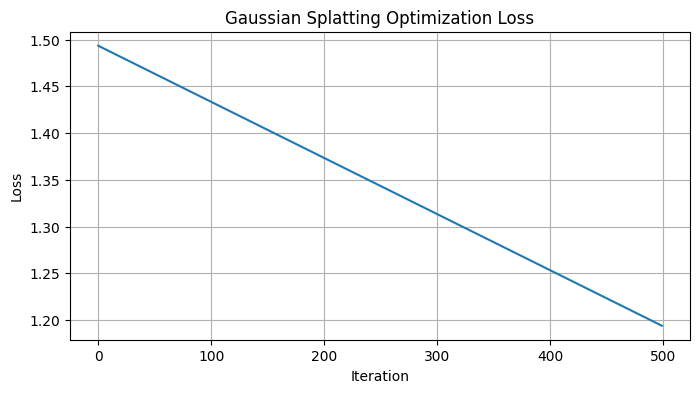

In [123]:
# Test Gaussian splatting reconstruction
instance_id = "P03_02_01"
t_sec = 5.0

print(f"Testing Gaussian splatting reconstruction for {instance_id} at t={t_sec}s")
gs_model, roi_3d, losses = reconstruct_with_gaussian_splatting(
    instance_id,
    t_sec,
    yolo_model,
    intrinsic_params,
    extrinsics,
    fp_poses,
    conf=0.25,
    num_iterations=500  # Start with fewer iterations for testing
)

if gs_model is not None:
    print(f"\nOptimization complete!")
    print(f"Final loss: {losses[-1]:.4f}")
    print(f"Gaussian model has {gs_model.num_gaussians} Gaussians")
    
    # Visualize loss curve
    plt.figure(figsize=(8, 4))
    plt.plot(losses)
    plt.xlabel('Iteration')
    plt.ylabel('Loss')
    plt.title('Gaussian Splatting Optimization Loss')
    plt.grid(True)
    plt.show()